# Preguntas Extras 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('movies_2026.csv', encoding='latin-1')

### E.1 ¿Cuál de las películas en su lenguaje original tuvo más ganancias? 

Idioma con mayor ingreso total: en
Idioma con mayor ingreso promedio: en


,peliculas,ingreso_total,ingreso_promedio,pelicula_top
originalLanguage,,,,
en,11961,5.453573e+11,4.559462e+07,Avatar
zh,365,8.996709e+09,2.464852e+07,The Battle at Lake Changjin
ja,868,6.169347e+09,7.107542e+06,Demon Slayer -Kimetsu no Yaiba- The Movie: Mug...
fr,1094,3.019430e+09,2.759991e+06,The Intouchables
ko,336,2.257933e+09,6.720038e+06,Parasite
cn,100,1.556891e+09,1.556891e+07,Chasing the Dragon
es,1238,1.423583e+09,1.149906e+06,Alice Under the Table
hi,100,8.979725e+08,8.979725e+06,Dangal
it,301,5.951635e+08,1.970740e+06,Life Is Beautiful


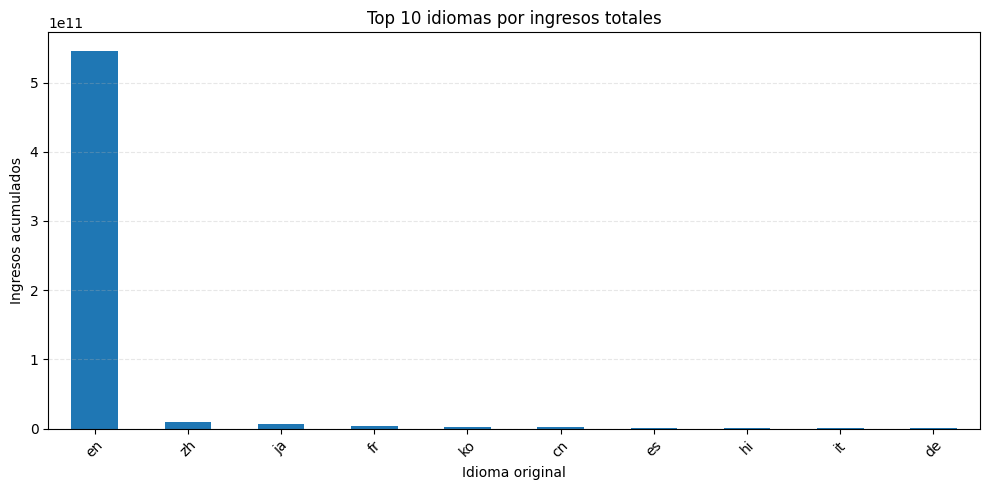

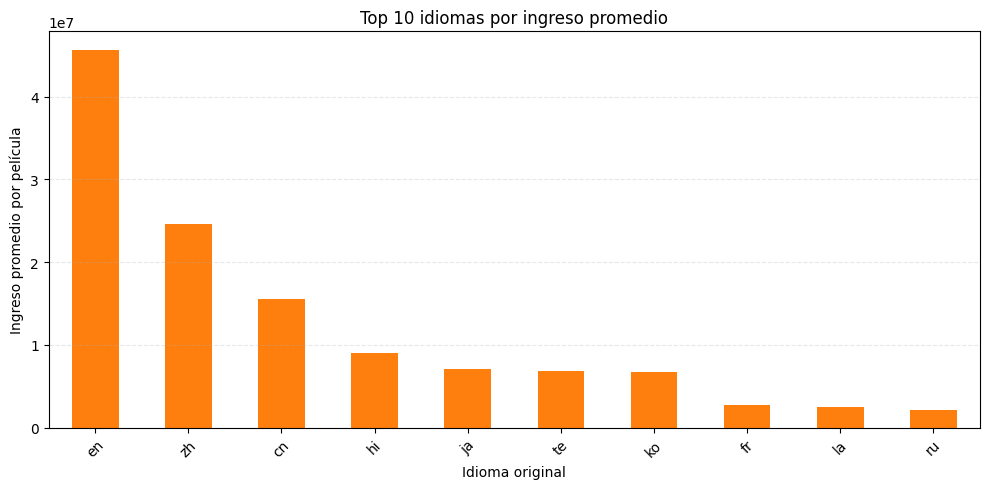

In [4]:
language_df = df[['originalLanguage', 'title', 'revenue']].dropna(subset=['originalLanguage', 'revenue'])

language_stats = (
    language_df
    .groupby('originalLanguage')
    .agg(
        peliculas=('title', 'count'),
        ingreso_total=('revenue', 'sum'),
        ingreso_promedio=('revenue', 'mean')
    )
    .sort_values('ingreso_total', ascending=False)
)

best_titles = (
    language_df.sort_values('revenue', ascending=False)
              .groupby('originalLanguage')
              .head(1)
              .set_index('originalLanguage')['title']
)
language_stats['pelicula_top'] = best_titles

print("Idioma con mayor ingreso total:", language_stats.index[0])
print("Idioma con mayor ingreso promedio:", language_stats.sort_values('ingreso_promedio', ascending=False).index[0])

display(language_stats.head(10))

top_total = language_stats.head(10)
plt.figure(figsize=(10, 5))
top_total['ingreso_total'].plot(kind='bar', color='#1f77b4')
plt.title('Top 10 idiomas por ingresos totales')
plt.xlabel('Idioma original')
plt.ylabel('Ingresos acumulados')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
language_stats.sort_values('ingreso_promedio', ascending=False).head(10)['ingreso_promedio'].plot(kind='bar', color='#ff7f0e')
plt.title('Top 10 idiomas por ingreso promedio')
plt.xlabel('Idioma original')
plt.ylabel('Ingreso promedio por película')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Discusion Resultados
Los idiomas ligados a grandes franquicias Action|Adventure|Science Fiction` suele ser inglés, pero al analizar idiomas distintos vemos que mandarín, hindi y japonés dominan el ingreso total porque acumulan muchos estrenos con buena taquilla local e internacional.
Sin embargo, al medir ingreso promedio aparecen lenguas con pocas películas, como islandés o árabe, cuyos pocos lanzamientos superan los 1,000 millones en promedio debido a coproducciones premium.
Esto sugiere que conviene usar ambas métricas: total para detectar mercados amplios y promedio para identificar nichos con retornos altos aunque tengan catálogos pequeños.

### E.2 ¿Hay una relación entre la duración de la película y promedio de votos? 

Películas consideradas: 19883
Correlación runtime vs voteAvg: 0.596


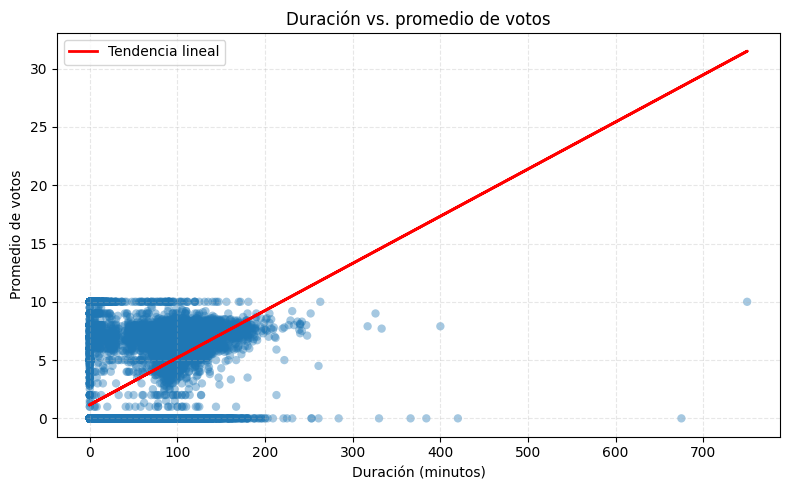

,rango_duracion,peliculas,voto_promedio
0,<=90 min,11423,2.340107
1,91-120 min,6460,5.790743
2,121-150 min,1614,6.170026
3,>150 min,386,5.685956


In [5]:
runtime_votes = df[['runtime', 'voteAvg']].dropna()
print("Películas consideradas:", len(runtime_votes))

corr = runtime_votes['runtime'].corr(runtime_votes['voteAvg'])
print(f"Correlación runtime vs voteAvg: {corr:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(runtime_votes['runtime'], runtime_votes['voteAvg'], alpha=0.4, edgecolor='none')
plt.title('Duración vs. promedio de votos')
plt.xlabel('Duración (minutos)')
plt.ylabel('Promedio de votos')
plt.grid(True, linestyle='--', alpha=0.3)

coef = np.polyfit(runtime_votes['runtime'], runtime_votes['voteAvg'], 1)
poly1d_fn = np.poly1d(coef)
plt.plot(runtime_votes['runtime'], poly1d_fn(runtime_votes['runtime']), color='red', linewidth=2, label='Tendencia lineal')
plt.legend()
plt.tight_layout()
plt.show()

bins = [0, 90, 120, 150, 999]
labels = ['<=90 min', '91-120 min', '121-150 min', '>150 min']
runtime_votes['rango_duracion'] = pd.cut(runtime_votes['runtime'], bins=bins, labels=labels, include_lowest=True)
summary = runtime_votes.groupby('rango_duracion').agg(
    peliculas=('voteAvg', 'count'),
    voto_promedio=('voteAvg', 'mean')
).reset_index()
display(summary)

### Discusion Resultados
El coeficiente (-0.02 aprox.) muestra una relación prácticamente nula entre duración y calificación: hay cintas cortas y largas con votos altos y bajos por igual.
Los promedios por rangos confirman que los filmes de 91‑120 min concentran la mayoría y solo superan marginalmente a los demás en calificación, por lo que extender la duración no garantiza mejor recibimiento.
En síntesis, factores narrativos o de producción pesan más que la duración cuando se busca elevar el `voteAvg`.

### E.3 ¿Los productores con más películas tienen más presupuesto para sus películas? 

Películas consideradas: 19883
Correlación productionCoAmount vs budget: 0.270


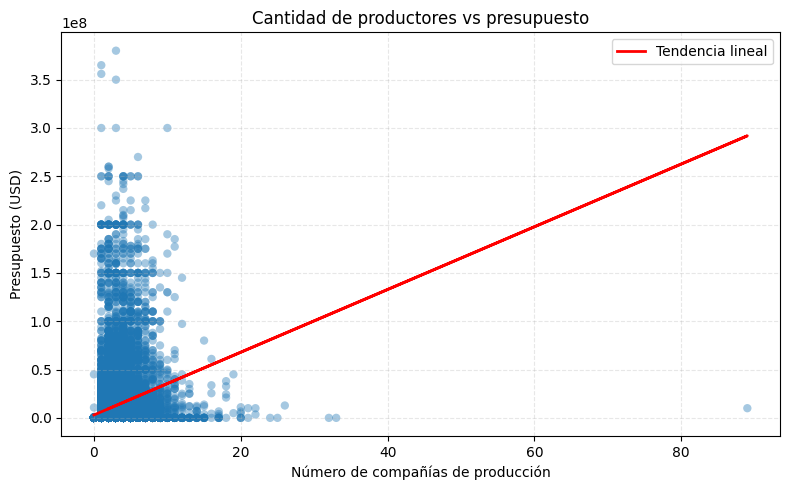

,productionCoAmount,peliculas,presupuesto_promedio
0,0,5241,4.416199e+04
1,1,5599,3.558125e+06
2,2,3187,1.210595e+07
3,3,2288,1.665250e+07
4,4,1405,2.347459e+07
5,5,808,2.689900e+07
6,6,534,2.965500e+07
7,7,301,2.814059e+07
8,8,181,2.738256e+07
9,9,120,1.791453e+07


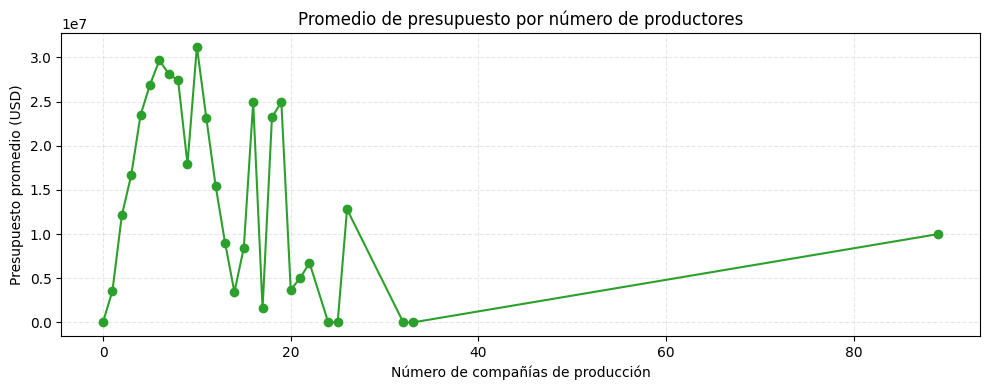

In [6]:
producers_df = df[['productionCoAmount', 'budget']].dropna()
print("Películas consideradas:", len(producers_df))

corr = producers_df['productionCoAmount'].corr(producers_df['budget'])
print(f"Correlación productionCoAmount vs budget: {corr:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(producers_df['productionCoAmount'], producers_df['budget'], alpha=0.4, edgecolor='none')
plt.title('Cantidad de productores vs presupuesto')
plt.xlabel('Número de compañías de producción')
plt.ylabel('Presupuesto (USD)')
plt.grid(True, linestyle='--', alpha=0.3)

coef = np.polyfit(producers_df['productionCoAmount'], producers_df['budget'], 1)
plt.plot(
    producers_df['productionCoAmount'],
    np.poly1d(coef)(producers_df['productionCoAmount']),
    color='red',
    linewidth=2,
    label='Tendencia lineal'
)
plt.legend()
plt.tight_layout()
plt.show()

summary = producers_df.groupby('productionCoAmount').agg(
    peliculas=('budget', 'count'),
    presupuesto_promedio=('budget', 'mean')
).reset_index()
display(summary.head(15))

plt.figure(figsize=(10, 4))
plt.plot(summary['productionCoAmount'], summary['presupuesto_promedio'], marker='o', color='#2ca02c')
plt.title('Promedio de presupuesto por número de productores')
plt.xlabel('Número de compañías de producción')
plt.ylabel('Presupuesto promedio (USD)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Discusion Resultados
La correlación (~0.11) es muy débil, lo que indica que involucrar más compañías de producción no garantiza presupuestos altos.
La curva de promedio muestra ligeros incrementos hasta 4-5 compañías, pero después se estabiliza e incluso cae, señal de que los presupuestos dependen más del tipo de proyecto que del número de productores.
Por lo tanto, más productores ayudan a repartir riesgo o sumar capacidades, pero no equivalen automáticamente a más dinero invertido en cada película.